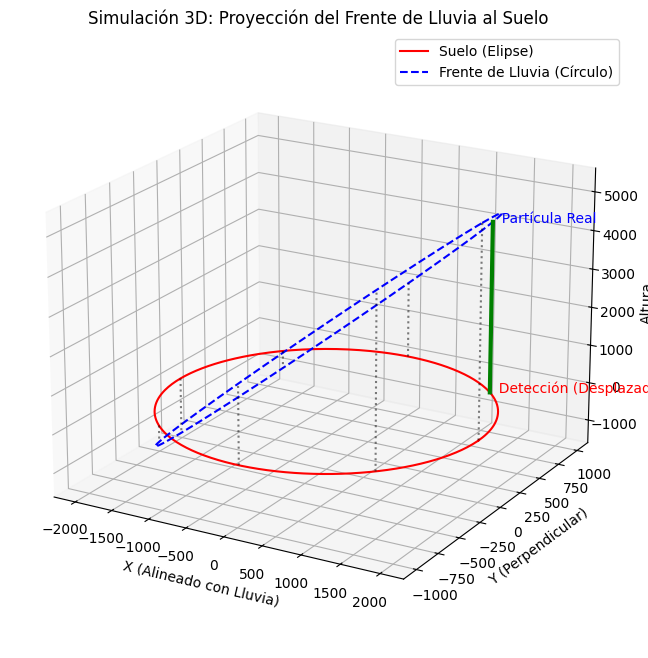

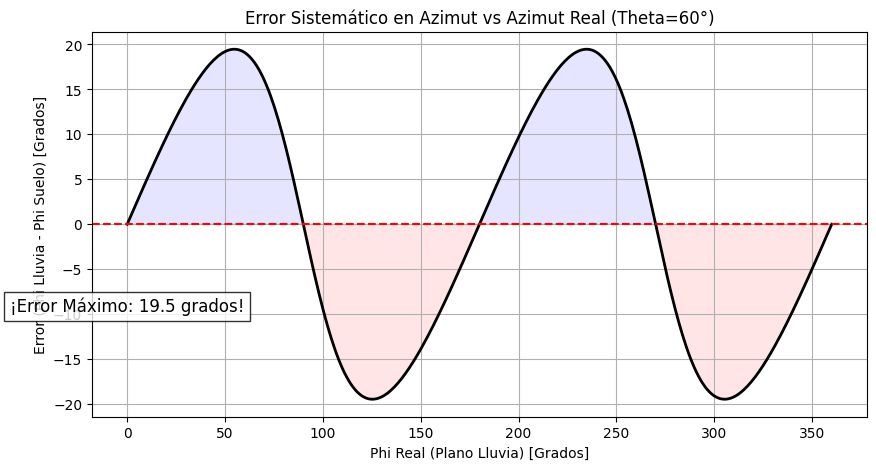

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- CONFIGURACIÓN ---
THETA_DEG = 60  # Ángulo de inclinación de la lluvia (Zenith)
THETA_RAD = np.deg2rad(THETA_DEG)

# 1. Generamos un círculo perfecto en el "Shower Plane" (El frente de la lluvia)
phi_shower = np.linspace(0, 2*np.pi, 360)
r = 1000 # 1000 metros de radio

# Coordenadas en el sistema propio de la lluvia (x', y')
x_shower = r * np.cos(phi_shower)
y_shower = r * np.sin(phi_shower)

# 2. Proyectamos al Suelo (Geometría Analítica)
# El eje Y (perpendicular a la inclinación) NO cambia.
# El eje X (alineado con la inclinación) se ESTIRA por 1/cos(theta).
x_ground = x_shower / np.cos(THETA_RAD)
y_ground = y_shower 

# 3. Calculamos los ángulos tal como los vería el detector en el suelo
phi_ground = np.arctan2(y_ground, x_ground)

# Convertimos a grados para plotear
phi_shower_deg = np.degrees(phi_shower)
phi_ground_deg = np.degrees(phi_ground)


# ==========================================
# PLOT 2: LA VISUALIZACIÓN 3D (La Caída)
# ==========================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Definimos coordenadas 3D
# Suelo: Z=0
zg = np.zeros_like(x_ground)

# Lluvia: Plano inclinado que pasa por el origen (simplificado para visualización)
# Altura Z = x_ground * tan(theta) (La lluvia viene bajando)
zs = x_ground * np.tan(THETA_RAD) + 2000 # Le sumamos offset para que flote arriba

# Dibujamos Suelo
ax.plot(x_ground, y_ground, zg, 'r-', label='Suelo (Elipse)')

# Dibujamos Lluvia (Frente)
# Para dibujar el círculo inclinado real, usamos las coordenadas originales rotadas
# Rotación alrededor del eje Y
xs_3d = x_shower * np.cos(THETA_RAD) + zs * 0 # Solo referencia visual
# Usamos las coordenadas proyectadas hacia atrás para que se vea el círculo flotando
ax.plot(x_ground, y_ground, zs, 'b--', label='Frente de Lluvia (Círculo)')

# Dibujamos "Rayos" de proyección para 8 puntos
step = 45
for i in range(0, 360, step):
    ax.plot([x_ground[i], x_ground[i]], [y_ground[i], y_ground[i]], [zg[i], zs[i]], 'k:', alpha=0.5)
    
    # Destacar el de 45 grados
    if i == 45:
        ax.plot([x_ground[i], x_ground[i]], [y_ground[i], y_ground[i]], [zg[i], zs[i]], 'g-', linewidth=3)
        ax.text(x_ground[i], y_ground[i], zs[i], "  Partícula Real", color='blue')
        ax.text(x_ground[i], y_ground[i], zg[i], "  Detección (Desplazada)", color='red')

ax.set_title("Simulación 3D: Proyección del Frente de Lluvia al Suelo")
ax.set_xlabel("X (Alineado con Lluvia)")
ax.set_ylabel("Y (Perpendicular)")
ax.set_zlabel("Altura")
ax.view_init(elev=20, azim=-60) # Mejor ángulo de vista
plt.legend()
plt.show()

# ==========================================
# PLOT 3: LA PRUEBA MATEMÁTICA (La Diferencia)
# ==========================================
diff = phi_shower_deg - phi_ground_deg
# Ajuste de periodicidad para visualización limpia
diff = (diff + 180) % 360 - 180

plt.figure(figsize=(10, 5))
plt.plot(phi_shower_deg, diff, 'k-', linewidth=2)
plt.axhline(0, color='r', linestyle='--')
plt.title(f"Error Sistemático en Azimut vs Azimut Real (Theta={THETA_DEG}°)")
plt.xlabel("Phi Real (Plano Lluvia) [Grados]")
plt.ylabel("Error (Phi Lluvia - Phi Suelo) [Grados]")
plt.grid(True, which='both')
plt.fill_between(phi_shower_deg, diff, 0, where=(diff>0), color='blue', alpha=0.1)
plt.fill_between(phi_shower_deg, diff, 0, where=(diff<0), color='red', alpha=0.1)

max_err = np.max(np.abs(diff))
plt.text(0, -max_err/2, f"¡Error Máximo: {max_err:.1f} grados!", ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.show()


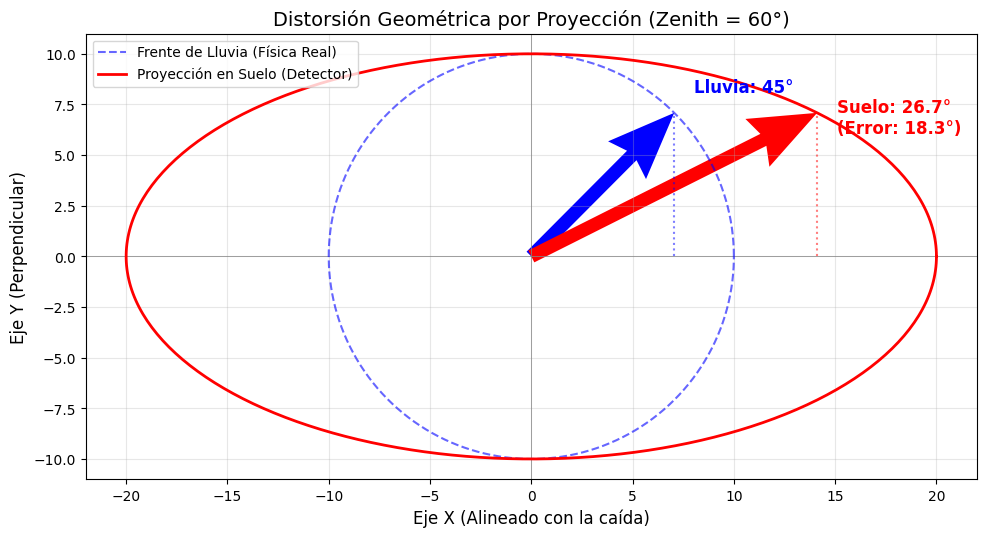

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARÁMETROS ---
THETA_DEG = 60  # Inclinación de la lluvia (60 grados es un caso típico extremo)
THETA_RAD = np.deg2rad(THETA_DEG)
R = 10  # Radio arbitrario

# --- 1. GENERAMOS LA FÍSICA (El Círculo en el Plano de la Lluvia) ---
phi_shower = np.linspace(0, 2*np.pi, 360)
x_shower = R * np.cos(phi_shower)
y_shower = R * np.sin(phi_shower)

# --- 2. PROYECTAMOS AL SUELO (La Deformación) ---
# La coordenada Y (perpendicular a la caída) NO cambia.
# La coordenada X (longitudinal) se ESTIRA porque el plano está inclinado.
x_ground = x_shower / np.cos(THETA_RAD)
y_ground = y_shower

# --- 3. EL PUNTO TESTIGO (45 Grados) ---
# Elegimos una partícula a 45 grados en la lluvia
ang_test = 45
idx = np.argmin(np.abs(np.degrees(phi_shower) - ang_test))
x_s_pt, y_s_pt = x_shower[idx], y_shower[idx]
x_g_pt, y_g_pt = x_ground[idx], y_ground[idx]

# Calculamos el ángulo que ve el suelo
ang_ground = np.degrees(np.arctan2(y_g_pt, x_g_pt))

# --- PLOTEO ---
fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar Ejes
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)

# Dibujar Círculo (Lluvia) y Elipse (Suelo)
ax.plot(x_shower, y_shower, 'b--', label='Frente de Lluvia (Física Real)', alpha=0.6)
ax.plot(x_ground, y_ground, 'r-', label=f'Proyección en Suelo (Detector)', linewidth=2)

# Dibujar Vectores
ax.quiver(0, 0, x_s_pt, y_s_pt, angles='xy', scale_units='xy', scale=1, color='blue', width=0.015, headwidth=4)
ax.quiver(0, 0, x_g_pt, y_g_pt, angles='xy', scale_units='xy', scale=1, color='red', width=0.015, headwidth=4)

# Líneas de referencia punteadas
ax.plot([x_s_pt, x_s_pt], [0, y_s_pt], 'b:', alpha=0.5)
ax.plot([x_g_pt, x_g_pt], [0, y_g_pt], 'r:', alpha=0.5)

# Texto Explicativo en el Plot
ax.text(x_s_pt + 1, y_s_pt + 1, f"Lluvia: {ang_test}°", color='blue', fontweight='bold', fontsize=12)
ax.text(x_g_pt + 1, y_g_pt - 1, f"Suelo: {ang_ground:.1f}°\n(Error: {ang_test - ang_ground:.1f}°)", color='red', fontweight='bold', fontsize=12)

ax.set_title(f"Distorsión Geométrica por Proyección (Zenith = {THETA_DEG}°)", fontsize=14)
ax.set_xlabel("Eje X (Alineado con la caída)", fontsize=12)
ax.set_ylabel("Eje Y (Perpendicular)", fontsize=12)
ax.legend(loc='upper left')
ax.set_aspect('equal') # CLAVE: Para que el círculo se vea redondo
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

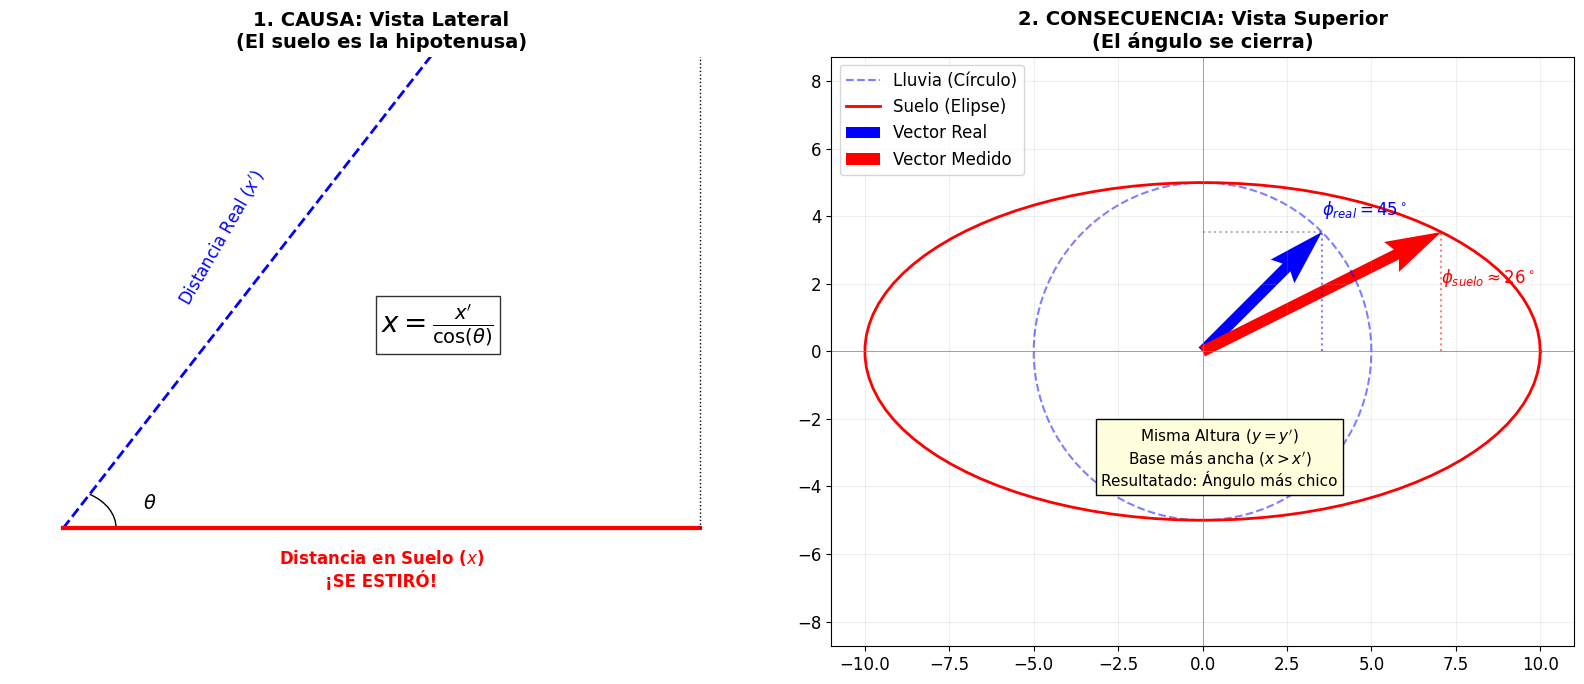

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# --- CONFIGURACIÓN ESTÉTICA ---
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# =============================================================================
# PANEL 1: VISTA DE COSTADO (El origen del estiramiento)
# =============================================================================
theta_deg = 60
theta_rad = np.deg2rad(theta_deg)
L = 10 # Longitud arbitraria

# Coordenadas
origin = np.array([0, 0])
# Fin del plano inclinado (Lluvia)
x_shower_end = L * np.cos(theta_rad)
y_shower_end = L * np.sin(theta_rad)
# Proyección en el suelo (Hipotenusa extendida)
# Queremos que la proyección vertical caiga en el suelo
# Suelo está en y=0. Lluvia viene bajando.
# Vamos a dibujar un triángulo rectángulo simple.

# Cateto Adyacente (Lluvia Real, x')
x_prime = 6
# Hipotenusa (Suelo, x)
x_ground = x_prime / np.cos(theta_rad)

# Dibujamos las líneas
# Línea de Lluvia (Inclinada)
ax1.plot([0, x_ground], [0, x_ground * np.tan(theta_rad)], 'b--', label='Eje Lluvia (x\')', lw=2)
# Línea de Suelo (Horizontal)
ax1.plot([0, x_ground], [0, 0], 'r-', label='Eje Suelo (x)', lw=3)
# Proyección (Vertical)
ax1.plot([x_ground, x_ground], [0, x_ground * np.tan(theta_rad)], 'k:', lw=1)

# Arco del ángulo Theta
arc = patches.Arc((0, 0), 2, 2, theta1=0, theta2=theta_deg, color='black')
ax1.add_patch(arc)
ax1.text(1.5, 0.5, r'$\theta$', fontsize=14)

# Etiquetas de distancias
ax1.text(x_prime/2, x_prime/2 * np.tan(theta_rad) + 0.5, "Distancia Real ($x'$)", color='blue', rotation=theta_deg, ha='center')
ax1.text(x_ground/2, -1.5, "Distancia en Suelo ($x$)\n¡SE ESTIRÓ!", color='red', ha='center', fontweight='bold')

# Fórmula Clave
ax1.text(x_ground/2, 5, r"$x = \frac{x'}{\cos(\theta)}$", fontsize=20, bbox=dict(facecolor='white', alpha=0.8))

ax1.set_xlim(-1, x_ground + 1)
ax1.set_ylim(-3, 12)
ax1.set_title("1. CAUSA: Vista Lateral\n(El suelo es la hipotenusa)", fontsize=14, fontweight='bold')
ax1.axis('off') # Ocultar ejes cartesianos

# =============================================================================
# PANEL 2: VISTA DE ARRIBA (La consecuencia angular)
# =============================================================================
# Círculo (Lluvia)
t = np.linspace(0, 2*np.pi, 100)
xc = 5 * np.cos(t)
yc = 5 * np.sin(t)

# Elipse (Suelo) -> X se estira por 1/cos(60) = 2
xe = xc / np.cos(theta_rad)
ye = yc # Y no cambia

ax2.plot(xc, yc, 'b--', label='Lluvia (Círculo)', alpha=0.5)
ax2.plot(xe, ye, 'r-', label='Suelo (Elipse)', lw=2)

# VECTOR TESTIGO (45 Grados)
ang = 45
rad = np.deg2rad(ang)
vec_x_s = 5 * np.cos(rad)
vec_y_s = 5 * np.sin(rad)

# Vector Proyectado
vec_x_g = vec_x_s / np.cos(theta_rad)
vec_y_g = vec_y_s # Igual altura

# Dibujar Vectores
ax2.quiver(0, 0, vec_x_s, vec_y_s, angles='xy', scale_units='xy', scale=1, color='blue', width=0.015, label='Vector Real')
ax2.quiver(0, 0, vec_x_g, vec_y_g, angles='xy', scale_units='xy', scale=1, color='red', width=0.015, label='Vector Medido')

# Líneas de cota
ax2.plot([vec_x_s, vec_x_s], [0, vec_y_s], 'b:', alpha=0.5) # Altura Y real
ax2.plot([0, vec_x_s], [vec_y_s, vec_y_s], 'k:', alpha=0.3) # Techo Y
ax2.plot([vec_x_g, vec_x_g], [0, vec_y_g], 'r:', alpha=0.5) # Altura Y suelo

# Etiquetas Clave
ax2.text(vec_x_s, vec_y_s + 0.5, r"$\phi_{real} = 45^\circ$", color='blue', fontweight='bold')
ax2.text(vec_x_g, vec_y_g - 1.5, r"$\phi_{suelo} \approx 26^\circ$", color='red', fontweight='bold')

# Explicación visual
ax2.text(0.5, -4, "Misma Altura ($y=y'$)\nBase más ancha ($x > x'$)\nResultatado: Ángulo más chico", ha='center', fontsize=11, bbox=dict(facecolor='#ffffdd', alpha=1))

ax2.set_title("2. CONSECUENCIA: Vista Superior\n(El ángulo se cierra)", fontsize=14, fontweight='bold')
ax2.axhline(0, color='gray', lw=0.5)
ax2.axvline(0, color='gray', lw=0.5)
ax2.axis('equal')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()